# Tutorial 0 — A multimodal galaxy dataset

A galaxy is not a single number or a single picture. It is a bundle of very
different kinds of measurements at once: a resolved **image**, a few **curves**
(how it formed stars over time, how matter is distributed with radius), and a
handful of **scalars** (its mass, size, star-formation rate). Each of these is a
*modality* — a distinct view of the same object, in its own shape and units.

This tutorial series builds a model that learns the **joint distribution** of all
these modalities, so that it can take **any subset** of a galaxy's properties and
predict **any other subset** — for example the star-formation history and
dark-matter profile from just the face-on image, or the image from a few scalars.

This first notebook does none of that modelling. It simply **looks at the data**:
what modalities each galaxy carries, what they mean physically, and — importantly —
**how much they vary from galaxy to galaxy**. That variation is the whole reason a
model is interesting: even galaxies that look similar in their scalars can have
quite different images, histories, and profiles.

We use the redshift **z = 0** snapshot (`Snap99`) of the IllustrisTNG **TNG-100**
cosmological simulation, concatenated into a single file, so everything here is
small and fast to load. (Later tutorials train on a larger multi-redshift set —
five snapshots spanning z = 0.0 → 0.4.)

### The modalities we will model
| # | Modality | Array | Physical meaning |
|---|----------|-------|------------------|
| 1 | Galaxy face-on image | `star_faceon` `(8,128,128)` | 8-band stellar photometry, angular-momentum aligned |
| 2 | Star-formation history | `sfh` `(2,24)` | log SFR vs lookback time (0–12 Gyr) |
| 3 | Gas density profile | `gas_profile` `(2,20)` | log ρ_gas vs r/r200 |
| 4 | Dark-matter density profile | `dm_profile` `(2,20)` | log ρ_DM vs r/r200 |
| 5–8 | Scalars | `sfr, mstar, mhalo, r200` `(,)` | total SFR, stellar mass, halo mass, virial radius |

All quantities are already in physically sensible (mostly log) units.

### Where this is going
A transformer can only read one kind of input: a sequence of discrete tokens. So
the rest of the series follows a standard two-stage recipe for turning this grab-bag
of modalities into something a single transformer can model:

1. **Codecs (Tutorial 1)** — *tokenize* every modality into a short sequence of
   discrete integer tokens, with a small per-modality auto-encoder / quantizer.
2. **Transformer (Tutorial 2)** — train one masked multimodal transformer over the
   concatenated token streams, so it can fill in any missing modality from the rest.

For now, though, we just get to know the data.

## Setup

We point Python at the local copy of the `aion` / `sim` source code that ships with the
tutorial, and load the concatenated z = 0 file **lazily** (`mmap_mode="r"`) so we never
pull the full ~1 GB into RAM — we only read the small slices we plot.

> **Data.** The z = 0 snapshot is pulled from the Hugging Face Hub repo
> [`yueyingn/multimodal-galaxy-tutorial`](https://huggingface.co/yueyingn/multimodal-galaxy-tutorial) and downloads
> automatically on first use (into `data/`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))   # prefer the tutorial's local aion/ + sim/

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sim.hub import data_path
DATA_PATH = data_path("Snap99.npz")     # local data/, else downloaded from the HF Hub

data = np.load(DATA_PATH, mmap_mode="r")
N = data["mhalo"].shape[0]
print(f"z=0 galaxies: {N}\n")
for k in data.files:
    print(f"  {k:14s} {tuple(data[k].shape)}  {data[k].dtype}")

z=0 galaxies: 3878

  star_faceon    (3878, 8, 128, 128)  float16
  sfh            (3878, 2, 24)  float32
  gas_profile    (3878, 2, 20)  float32
  dm_profile     (3878, 2, 20)  float32
  scale_factor   (3878,)  float32
  r200           (3878,)  float32
  fofid          (3878,)  float32
  mstar          (3878,)  float32
  mhalo          (3878,)  float32
  sfr            (3878,)  float32
  mbh            (3878,)  float32
  egyRM          (3878,)  float32
  RMpow          (3878,)  float32


## A single galaxy, across all its modalities

The clearest way to understand the dataset is to take **one halo** and look at every
modality it carries. We pick a deterministic *star-forming, intermediate-mass* galaxy
so that its image, SFH and profiles all show real structure. As we will see below,
"intermediate-mass and star-forming" does **not** mean "average" — once we compare
this galaxy's profiles against its peers, it turns out to be a fairly atypical object.

In [2]:
mhalo_all = np.asarray(data["mhalo"])
mstar_all = np.asarray(data["mstar"])
sfr_all   = np.asarray(data["sfr"])

# Deterministically pick a star-forming, mid-mass galaxy to "portrait".
mask = (sfr_all > -0.5) & (mstar_all > 10.5) & (mstar_all < 11.3)
cands = np.where(mask)[0]
HALO = int(cands[len(cands) // 2]) if len(cands) else 0
print(f"Selected halo index: {HALO}")

# Its scalar labels (modalities 5-8, all in log units).
print("\nScalar labels for this halo:")
print(f"  log10 SFR     = {float(data['sfr'][HALO]):.3f}   (M_sun/yr)")
print(f"  log10 M_star  = {float(data['mstar'][HALO]):.3f}   (M_sun, 35 ckpc/h aperture)")
print(f"  log10 M_halo  = {float(data['mhalo'][HALO]):.3f}   (M_sun, M_crit200)")
print(f"  log10 r200    = {float(data['r200'][HALO]):.3f}   (ckpc/h)")

Selected halo index: 1121

Scalar labels for this halo:
  log10 SFR     = -0.016   (M_sun/yr)
  log10 M_star  = 10.565   (M_sun, 35 ckpc/h aperture)
  log10 M_halo  = 12.251   (M_sun, M_crit200)
  log10 r200    = 2.238   (ckpc/h)


### Modality 1 — Galaxy face-on image (`star_faceon`)

Shape `(8, 128, 128)`: eight broad-band filters **U, B, V, K, g, r, i, z** (AB system)
in a 50 × 50 ckpc/h field of view, projected in the galaxy's **angular-momentum frame**
(so disks appear face-on). Stored as `log(1 + flux)`. Here are all 8 bands of our halo
(a per-image 1–99 percentile stretch is applied for *display* only).

In [3]:
def stretch(im):
    lo, hi = np.percentile(im, 1), np.percentile(im, 99)
    return np.clip((im - lo) / max(hi - lo, 1e-6), 0, 1)

BAND_NAMES = ["U", "B", "V", "K", "g", "r", "i", "z"]
img = np.asarray(data["star_faceon"][HALO])   # (8, 128, 128)

fig, axes = plt.subplots(1, 8, figsize=(16, 2.3))
for b, ax in enumerate(axes):
    ax.imshow(stretch(img[b]), cmap="inferno", origin="lower")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"band {BAND_NAMES[b]}", fontsize=10)
fig.suptitle(f"Halo {HALO} — face-on stellar photometry (log1p flux)", y=1.12)
fig.tight_layout(); plt.show()

ValueError: Unsupported dtype

<Figure size 1152x165.6 with 8 Axes>

### Modality 2 — Star-formation history (`sfh`)

Shape `(2, 24)`. Row 0 is a **fixed** lookback-time grid (24 bins, 0–12 Gyr, 0.5 Gyr
each); row 1 is `log10(SFR + 1e-6)` in each bin. The time grid is identical for every
galaxy, so the codec in Tutorial 1 only needs to encode the SFR row.

### Modalities 3 & 4 — Radial density profiles (`gas_profile`, `dm_profile`)

Shape `(2, 20)` each. Row 0 is normalized radius **r / r200** (fixed grid, 20 bins in
[0, 1]); row 1 is `log10(ρ)` in code units. The dark-matter profile is the classic
peaked-then-declining halo profile; the gas profile is shaped by cooling and feedback.

**Is this galaxy typical?** A density profile is largely set by the halo's mass, so
the fair question is: among galaxies of the *same* halo mass, is *this* one's profile
ordinary? Below we draw the **mass-matched population** (all halos within ±0.15 dex in
`log M_halo`) as a shaded 16–84th-percentile band with its median (dotted), and overlay
our halo (solid). The SFH is shown on the left for reference.

mass-matched sample: 726 halos at log M_halo = 12.25 +/- 0.15


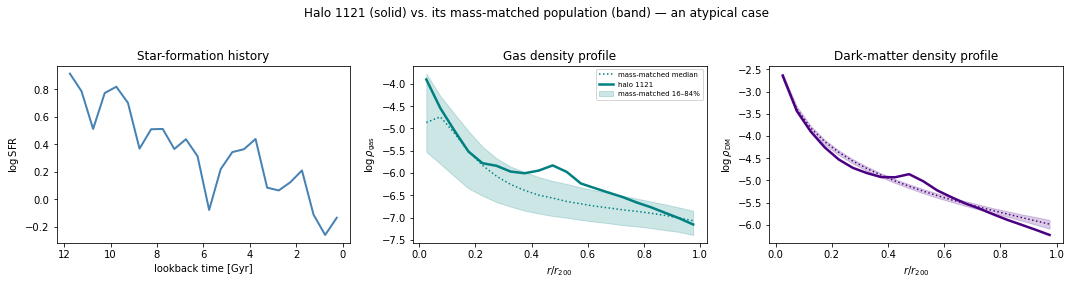

In [4]:
sfh = np.asarray(data["sfh"][HALO])                     # (2, 24)
rad = np.asarray(data["gas_profile"][0, 0, :])          # shared r/r200 grid

# log-density rows for the whole population (clip the empty-bin floor for display)
gas_rho = np.clip(np.asarray(data["gas_profile"][:, 1, :]), -10, None)  # (N, 20)
dm_rho  = np.clip(np.asarray(data["dm_profile"][:, 1, :]),  -10, None)

# Mass-matched comparison sample: halos within +/-0.15 dex of our halo's mass.
mm = np.abs(mhalo_all - mhalo_all[HALO]) < 0.15
gas_band = np.percentile(gas_rho[mm], [16, 50, 84], axis=0)   # (3, 20)
dm_band  = np.percentile(dm_rho[mm],  [16, 50, 84], axis=0)
print(f"mass-matched sample: {int(mm.sum())} halos at log M_halo = {mhalo_all[HALO]:.2f} +/- 0.15")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
# SFH
ax[0].plot(sfh[0], sfh[1], color="steelblue", lw=2)
ax[0].invert_xaxis()   # present day on the right
ax[0].set_xlabel("lookback time [Gyr]"); ax[0].set_ylabel(r"$\log {\rm SFR}$")
ax[0].set_title("Star-formation history")
# gas profile vs mass-matched band
ax[1].fill_between(rad, gas_band[0], gas_band[2], color="teal", alpha=0.20,
                   label="mass-matched 16–84%")
ax[1].plot(rad, gas_band[1], color="teal", lw=1.5, ls=":", label="mass-matched median")
ax[1].plot(rad, gas_rho[HALO], color="teal", lw=2.5, label=f"halo {HALO}")
ax[1].set_xlabel(r"$r / r_{200}$"); ax[1].set_ylabel(r"$\log \rho_{\rm gas}$")
ax[1].set_title("Gas density profile"); ax[1].legend(fontsize=7)
# DM profile vs mass-matched band
ax[2].fill_between(rad, dm_band[0], dm_band[2], color="indigo", alpha=0.20)
ax[2].plot(rad, dm_band[1], color="indigo", lw=1.5, ls=":")
ax[2].plot(rad, dm_rho[HALO], color="indigo", lw=2.5)
ax[2].set_xlabel(r"$r / r_{200}$"); ax[2].set_ylabel(r"$\log \rho_{\rm DM}$")
ax[2].set_title("Dark-matter density profile")
fig.suptitle(f"Halo {HALO} (solid) vs. its mass-matched population (band) — an atypical case", y=1.03)
fig.tight_layout(); plt.show()

Notice how the solid curves wander **outside** the mass-matched band: this galaxy's
**gas profile sits high** (it is unusually gas-rich for its mass), and both its gas and
dark-matter profiles carry a distinct **bump near `r/r200 ≈ 0.45`** — a substructure /
infalling clump — that the smooth population median completely washes out. So even at
fixed halo mass, the profiles are not a single universal curve: there is real
galaxy-to-galaxy **scatter**, and our "ordinary-looking" galaxy is a fairly atypical
draw from it.

This is exactly why the modelling in later tutorials is worthwhile. The mapping from
scalars (like halo mass) to a profile is **not** a deterministic function — you cannot
just read off the median. A useful model has to capture the *distribution* of profiles
and use the **other** modalities (the image, the SFH) to pin down which kind of object
this actually is.

### Modalities 5–8 — Scalars

`sfr`, `mstar`, `mhalo`, `r200` are single numbers per galaxy (already in log scale) —
we printed them for this halo above. In Tutorial 1 each becomes a **single token** via a
cumulative-distribution-function quantizer.

That is the full multimodal "portrait" of one galaxy: an 8-band image, a 24-step
history, two 20-step profiles, and four scalars. The transformer learns the joint
distribution of all of these across the population.

## The galaxy population

Finally, a look at the population these halos are drawn from: the **massive** end of
TNG-100 (log M_halo/M_⊙ ≳ 11), spanning group to cluster scales. Below are the 1-D
distributions of the three headline scalars.

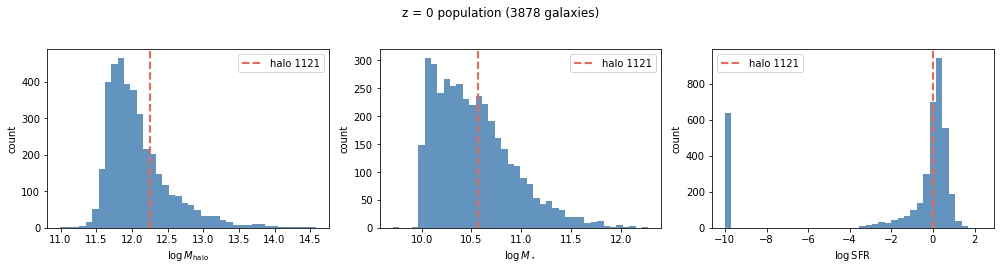

Quenched fraction (log SFR at floor): 16.4%


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, (v, lab) in zip(ax, [(mhalo_all, r"$\log M_{\rm halo}$"),
                            (mstar_all, r"$\log M_\star$"),
                            (sfr_all,   r"$\log {\rm SFR}$")]):
    a.hist(v, bins=40, color="steelblue", alpha=0.85)
    a.axvline(float(v[HALO]), color="tomato", lw=2, ls="--", label=f"halo {HALO}")
    a.set_xlabel(lab); a.set_ylabel("count"); a.legend()
fig.suptitle(f"z = 0 population ({N} galaxies)", y=1.03)
fig.tight_layout(); plt.show()

print(f"Quenched fraction (log SFR at floor): {float((sfr_all <= -5).mean()):.1%}")

## Recap: from modalities to tokens

Tutorial 1 turns each modality into discrete tokens with a per-modality codec:

| Modality | Token key | # tokens | codec vocab | Codec family |
|----------|-----------|---------:|------:|--------------|
| galaxy face-on image | `tok_sim_galaxy_image` | 1024 | 625 | 2-D MagVit VQ-AE + FSQ |
| star-formation history | `tok_sim_sfh` | 6 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| gas density profile | `tok_sim_gas_profile` | 5 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| DM density profile | `tok_sim_dm_profile` | 5 | 1024 | 1-D ConvNeXt VQ-AE + LFQ |
| scalars (sfr, mstar, …) | `tok_sim_*` | 1 each | 1024 | scalar quantile quantizer |

➡️ Continue with **`tutorial-1-codecs.ipynb`**.